<a href="https://colab.research.google.com/github/Johnogunlola/MRes-AI/blob/MRes/Aircraft_accident_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve)
from sklearn.model_selection import train_test_split

In [ ]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.neural_network import MLPClassifier

# Explainability
from sklearn.inspection import permutation_importance

# Optional SHAP (if installed)
try:
    import shap
    SHAP_AVAILABLE = True
except Exception:
    SHAP_AVAILABLE = False

# Optional SMOTE (not enabled by default due to high-dimensional sparse OHE)
try:
    from imblearn.over_sampling import SMOTE
    SMOTE_AVAILABLE = True
except Exception:
    SMOTE_AVAILABLE = False

In [ ]:
# from google.colab import files
# uploaded = files.upload()  # choose your CSV (e.g., Aircraft Accident Data.csv)

# Set your file name here (after upload)
CSV_PATH = 'Aircraft Accident Data.csv'  # change if your file name differs

def to_numeric_clean(series):
    """Robust numeric parser: remove non-numeric characters like '1,1', then to float."""
    return pd.to_numeric(series.astype(str).str.replace(r'[^0-9\-\.\+eE]+', '', regex=True), errors='coerce')

def plot_confusion_matrix(cm, labels, title='Confusion Matrix', path=None):
    plt.figure(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.title(title)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    if path:
        plt.savefig(path, dpi=200)
    plt.show()

In [ ]:
assert os.path.exists(CSV_PATH), f"CSV not found at: {CSV_PATH}"
df = pd.read_csv(CSV_PATH, low_memory=False, encoding='latin1')

# Some datasets store the event type under a long column name; handle both.
EVENT_COL = None
for cand in ['EventType', 'EventType = Accident (ACC) or Incidence (INC) or Occurrence (OCC)']:
    if cand in df.columns:
        EVENT_COL = cand
        break

# Filter to "ACC" (Accidents)
if EVENT_COL is not None:
    df = df[df[EVENT_COL].astype(str).str.contains('ACC', na=False)].copy()

# Target column (severity)
TARGET_COL = 'HighestInjuryLevel' if 'HighestInjuryLevel' in df.columns else 'SeverityLevel'
df[TARGET_COL] = df[TARGET_COL].astype(str).fillna('Unknown')

# Time column
assert 'Year' in df.columns, "The dataset must contain a 'Year' column."
df['Year'] = to_numeric_clean(df['Year'])

In [ ]:
# Exclude outcome/post-event columns
EXCLUDE_COLS = {
    TARGET_COL,
    'FatalInjuryCount', 'SeriousInjuryCount', 'MinorInjuryCount',
    'TotalInjuries', 'RiskScore', 'ProbableCause', 'AirCraftDamage',
    'HasSafetyRecommendations', 'ReportStatus', 'RepGenFlag'
}

# Candidate pre-flight feature columns (adjust to your dataset if needed)
candidate_cols = [
    'Month', 'DayOfWeek', 'Hour',
    'Country', 'State', 'City',
    'Latitude', 'Longitude',
    'Make', 'Model', 'AircraftCategory',
    'AirportID', 'AmateurBuilt', 'NumberOfEngines',
    'Scheduled', 'PurposeOfFlight', 'FAR',
    'WeatherCondition', 'Operator',
    'ModelYear', 'AircraftAge',
    'Season'
]
FEATURE_COLS = [c for c in candidate_cols if c in df.columns and c not in EXCLUDE_COLS]

# Engineer NightTime (pre-flight) from Hour if present
if 'Hour' in FEATURE_COLS:
    df['Hour'] = to_numeric_clean(df['Hour'])
    df['NightTime'] = ((df['Hour'] >= 18) | (df['Hour'] < 6)).astype(int)
    FEATURE_COLS += ['NightTime']

In [ ]:
# Primary task: Multiclass severity prediction BEFORE flight.
# Many rows have 'Unknown' severity; removing them improves signal.
INCLUDE_UNKNOWN = False  # set True if you want to keep 'Unknown' as a class

# Training: 2015–2022; Testing: 2023–2025
train_df = df[(df['Year'] >= 2015) & (df['Year'] <= 2022)].copy()
test_df  = df[(df['Year'] >= 2023) & (df['Year'] <= 2025)].copy()

# If excluding Unknown severity:
if not INCLUDE_UNKNOWN:
    train_df = train_df[train_df[TARGET_COL].str.lower() != 'unknown']
    test_df  = test_df[test_df[TARGET_COL].str.lower() != 'unknown']

# Prepare X / y
y_train = train_df[TARGET_COL].astype(str)
y_test  = test_df[TARGET_COL].astype(str)

# Clean numeric columns
numeric_cols = []
categorical_cols = []
for c in FEATURE_COLS:
    if c in {'Latitude', 'Longitude', 'NumberOfEngines', 'ModelYear', 'AircraftAge', 'Hour', 'Month', 'NightTime'}:
        numeric_cols.append(c)
    else:
        categorical_cols.append(c)

# Apply numeric cleaner to numeric columns
for df_ in (train_df, test_df):
    for col in numeric_cols:
        df_[col] = to_numeric_clean(df_[col])

# Cap aircraft age at 50 years (domain cap)
if 'AircraftAge' in numeric_cols:
    for df_ in (train_df, test_df):
        df_['AircraftAge'] = df_['AircraftAge'].clip(upper=50)

X_train = train_df[FEATURE_COLS].copy()
X_test  = test_df[FEATURE_COLS].copy()

print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")
print(f"Train class distribution:\n{y_train.value_counts()}")
print(f"Test class distribution:\n{y_test.value_counts()}")

Train size: (11977, 23), Test size: (3703, 23)
Train class distribution:
HighestInjuryLevel
nan        6158
Fatal      2727
Minor      1683
Serious    1409
Name: count, dtype: int64
Test class distribution:
HighestInjuryLevel
nan        2045
Fatal       717
Minor       504
Serious     437
Name: count, dtype: int64


In [ ]:
# Tree-friendly pipeline (sparse OHE ok)
preprocess_trees = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler(with_mean=False))
        ]), numeric_cols),
        ('cat', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))  # sparse by default
        ]), categorical_cols)
    ]
)

# MLP-friendly pipeline (dense OHE)
preprocess_mlp = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler(with_mean=False))
        ]), numeric_cols),
        ('cat', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
            ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))  # dense for MLP
        ]), categorical_cols)
    ]
)

# Sample weights: inverse frequency
class_counts = y_train.value_counts()
class_weights = {cls: (1.0 / cnt) for cls, cnt in class_counts.items()}
train_weights = y_train.map(class_weights).values

# (Optional) SMOTE (disabled by default)
USE_SMOTE = False and SMOTE_AVAILABLE  # change to True to try SMOTE on dense features
X_train_for_mlp = None; y_train_for_mlp = None
if USE_SMOTE and SMOTE_AVAILABLE:
    # Convert MLP preprocessed features to dense and apply SMOTE
    Xt_mlp = preprocess_mlp.fit_transform(X_train)
    if hasattr(Xt_mlp, 'toarray'):
        Xt_mlp = Xt_mlp.toarray()
    sm = SMOTE(random_state=42)
    Xt_mlp_res, y_train_res = sm.fit_resample(Xt_mlp, y_train)
    X_train_for_mlp, y_train_for_mlp = Xt_mlp_res, y_train_res
else:
    X_train_for_mlp = None
    y_train_for_mlp = None

In [ ]:
models = {
    'RandomForest': Pipeline(steps=[
        ('prep', preprocess_trees),
        ('clf', RandomForestClassifier(
            n_estimators=400, max_depth=None, random_state=42, n_jobs=-1, class_weight=None))
    ]),
    'GradientBoosting': Pipeline(steps=[
        ('prep', preprocess_trees),
        ('clf', GradientBoostingClassifier(random_state=42))
    ]),
    'ExtraTrees': Pipeline(steps=[
        ('prep', preprocess_trees),
        ('clf', ExtraTreesClassifier(
            n_estimators=600, max_depth=None, random_state=42, n_jobs=-1, class_weight=None))
    ]),
    'MLP': Pipeline(steps=[
        ('prep', preprocess_mlp),
        ('clf', MLPClassifier(
            hidden_layer_sizes=(128, 64),
            activation='relu',
            solver='adam',
            alpha=1e-4,
            batch_size=256,
            learning_rate='adaptive',
            max_iter=50,
            random_state=42))
    ])
}


===== Training RandomForest =====

===== Training GradientBoosting =====

===== Training ExtraTrees =====

===== Training MLP =====


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(



=== Model Comparison (Temporal Test Set) ===
              Model  Accuracy  Macro_F1  Weighted_F1  Macro_ROC_AUC_OVR
1  GradientBoosting  0.430462  0.383614     0.452677           0.660699
2        ExtraTrees  0.547124  0.343317     0.490051           0.640243
0      RandomForest  0.555225  0.342393     0.492213           0.651138
3               MLP  0.430732  0.333734     0.436464           0.590412


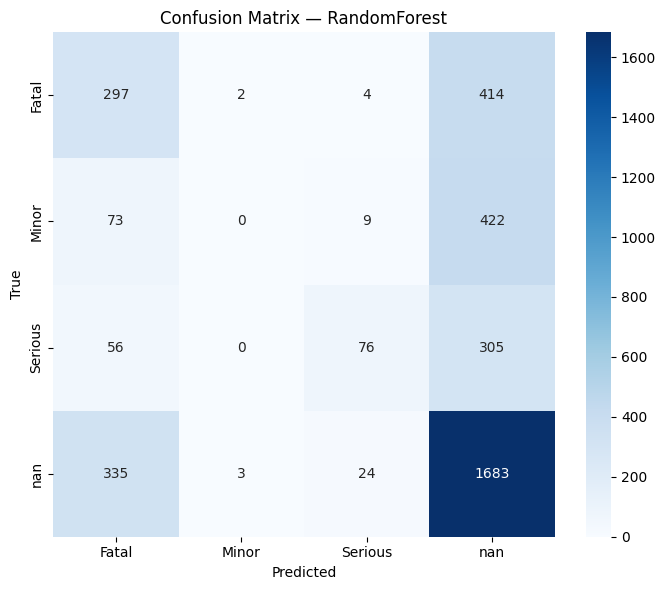

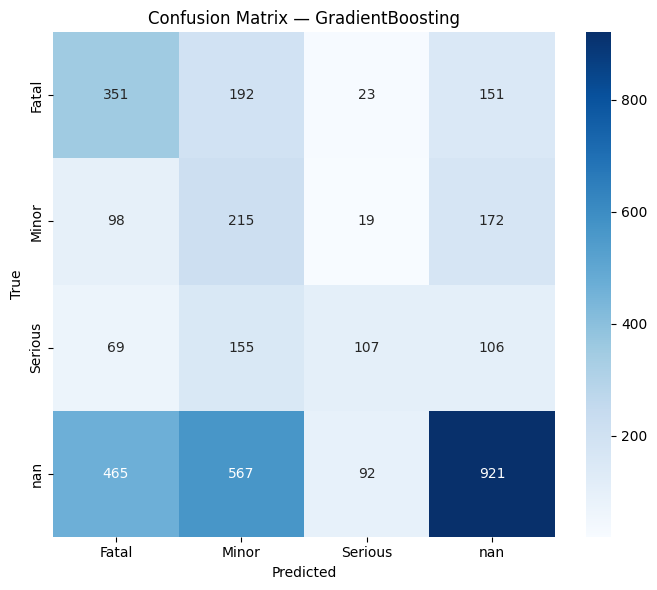

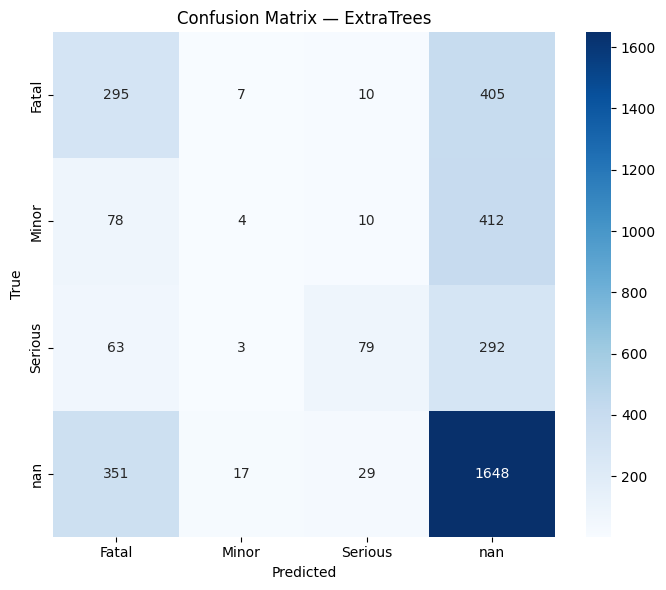

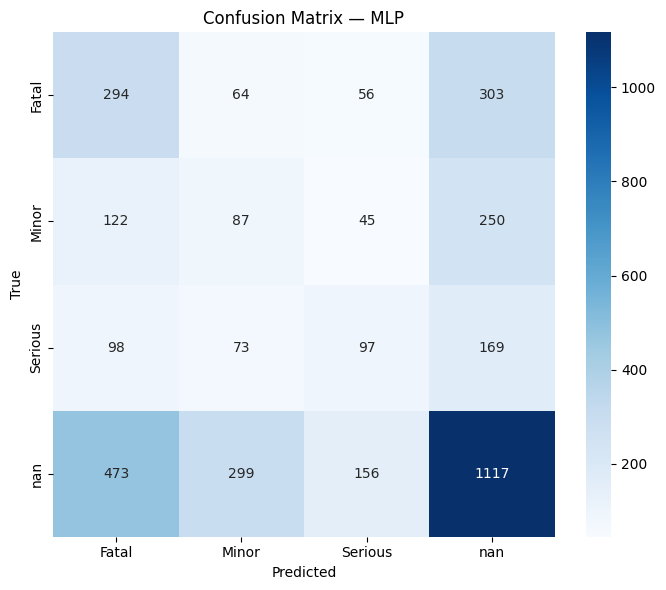

In [ ]:
eval_rows = []
per_model_cm = {}

for name, pipe in models.items():
    print(f"\n===== Training {name} =====")
    if name == 'MLP' and USE_SMOTE and X_train_for_mlp is not None:
        # Fit MLP on SMOTE-resampled dense training set
        pipe.named_steps['prep'].fit(X_train)  # fit preprocess to original train
        pipe.named_steps['clf'].fit(X_train_for_mlp, y_train_for_mlp)  # classifier on resampled features
        # Transform test for MLP for evaluation
        Xt_test_mlp = pipe.named_steps['prep'].transform(X_test)
        if hasattr(Xt_test_mlp, 'toarray'):
            Xt_test_mlp = Xt_test_mlp.toarray()
        y_pred = pipe.named_steps['clf'].predict(Xt_test_mlp)
        if hasattr(pipe.named_steps['clf'], 'predict_proba'):
            y_proba = pipe.named_steps['clf'].predict_proba(Xt_test_mlp)
        else:
            y_proba = None
    else:
        # Fit pipeline (sample weights on classifier step where supported)
        if name in ['RandomForest', 'GradientBoosting', 'ExtraTrees']:
            pipe.fit(X_train, y_train, clf__sample_weight=train_weights)
        else:
            pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)
        y_proba = pipe.predict_proba(X_test) if hasattr(pipe, 'predict_proba') else None

    # Metrics
    report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    accuracy = report['accuracy']
    macro_f1 = report['macro avg']['f1-score']
    weighted_f1 = report['weighted avg']['f1-score']

    # Macro ROC-AUC (One-vs-Rest), if proba available and >1 class
    try:
        classes_ = np.unique(y_test)
        if y_proba is not None and len(classes_) > 1:
            # Build one-vs-rest y_true matrix
            from sklearn.preprocessing import label_binarize
            y_test_bin = label_binarize(y_test, classes=classes_)
            auc_macro = roc_auc_score(y_test_bin, y_proba, average='macro', multi_class='ovr')
        else:
            auc_macro = np.nan
    except Exception:
        auc_macro = np.nan

    # Confusion matrix
    labels_sorted = sorted(y_test.unique())
    cm = confusion_matrix(y_test, y_pred, labels=labels_sorted)
    per_model_cm[name] = (cm, labels_sorted)

    # Save row
    eval_rows.append({
        'Model': name,
        'Accuracy': accuracy,
        'Macro_F1': macro_f1,
        'Weighted_F1': weighted_f1,
        'Macro_ROC_AUC_OVR': auc_macro
    })

# Compile evaluation table
eval_df = pd.DataFrame(eval_rows).sort_values(by='Macro_F1', ascending=False)
print("\n=== Model Comparison (Temporal Test Set) ===")
print(eval_df)

# Save evaluation CSV
eval_df.to_csv('model_comparison_temporal_test.csv', index=False)

# Plot confusion matrices
for name, (cm, labels_sorted) in per_model_cm.items():
    path = f'cm_{name}.png'
    plot_confusion_matrix(cm, labels_sorted, title=f'Confusion Matrix — {name}', path=path)

In [ ]:
# Use GradientBoosting pipeline for permutation importance on original (preprocessed) features
gb_pipe = models['GradientBoosting']
# Refit (already fitted, but safe to refit with sample weights)
gb_pipe.fit(X_train, y_train, clf__sample_weight=train_weights)

# Permutation importance on the original FEATURE_COLS (not post-OHE)
r = permutation_importance(gb_pipe, X_test, y_test, n_repeats=8, random_state=42)
perm_importance = pd.Series(r.importances_mean, index=FEATURE_COLS).sort_values(ascending=False)
perm_importance.to_csv('permutation_importance_gb.csv')
print("\nTop predictors by permutation importance (GB):")
print(perm_importance.head(15))

# Optional SHAP summary (Gradient Boosting)
if SHAP_AVAILABLE:
    try:
        # Fit preprocess alone to transform training data
        X_train_trans = gb_pipe.named_steps['prep'].fit_transform(X_train)
        gb_model = gb_pipe.named_steps['clf']
        explainer = shap.TreeExplainer(gb_model)
        # Sample for speed
        n_sample = min(2000, X_train_trans.shape[0])
        # If sparse, to dense
        if hasattr(X_train_trans, 'toarray'):
            X_train_trans_dense = X_train_trans.toarray()
        else:
            X_train_trans_dense = X_train_trans
        # SHAP values
        shap_values = explainer.shap_values(X_train_trans_dense[:n_sample])
        shap.summary_plot(shap_values, X_train_trans_dense[:n_sample], show=False)
        plt.savefig('shap_summary_gb.png', dpi=200, bbox_inches='tight')
        plt.close()
        print("Saved SHAP summary to shap_summary_gb.png")
    except Exception as e:
        print(f"SHAP plotting skipped due to: {e}")


Top predictors by permutation importance (GB):
WeatherCondition    0.058500
AirportID           0.046010
Country             0.037233
AircraftCategory    0.014279
Make                0.009519
FAR                 0.005772
NumberOfEngines     0.005367
AmateurBuilt        0.004591
Scheduled           0.003646
City                0.001485
Model               0.000911
Month               0.000439
ModelYear           0.000439
DayOfWeek           0.000135
AircraftAge         0.000000
dtype: float64
SHAP plotting skipped due to: GradientBoostingClassifier is only supported for binary classification right now!


In [ ]:
# Weather severity mapping
def weather_severity(series):
    # VMC (0), Unknown (0.5), IMC (1.0)
    return series.map({'VMC': 0.0, 'Unknown': 0.5, 'IMC': 1.0}).fillna(0.5)

# NightTime already engineered above if Hour present; re-ensure presence
for df_ in (train_df, test_df):
    if 'Hour' in df_.columns and 'NightTime' not in df_.columns:
        df_['NightTime'] = ((df_['Hour'] >= 18) | (df_['Hour'] < 6)).astype(int)

for df_ in (train_df, test_df):
    df_['WeatherSeverity'] = weather_severity(df_.get('WeatherCondition', pd.Series(index=df_.index)))
    # Normalize age to [0,1] with 50-year cap
    if 'AircraftAge' in df_.columns:
        max_age = max(train_df['AircraftAge'].dropna().max(), 1.0)
        df_['AgeNorm'] = (df_['AircraftAge'].fillna(0).clip(upper=50)) / max_age
    else:
        df_['AgeNorm'] = 0.0
    # NightTime bin
    df_['NightTimeBin'] = df_.get('NightTime', pd.Series(0, index=df_.index)).fillna(0).astype(int)

# Purpose-of-flight hazard index estimated from TRAIN historical distribution
if 'PurposeOfFlight' in train_df.columns:
    purpose_risk_map = train_df.groupby('PurposeOfFlight')[TARGET_COL] \
        .apply(lambda s: (s.isin(['Serious', 'Fatal']).mean()) if s.dtype == 'object' else 0.0) \
        .to_dict()
else:
    purpose_risk_map = {}

for df_ in (train_df, test_df):
    df_['PurposeRisk'] = df_.get('PurposeOfFlight', pd.Series(index=df_.index)) \
                           .map(purpose_risk_map).fillna(0.2)

# Derive normalized weights from GB permutation importance (grouped)
w_age      = float(perm_importance.get('AircraftAge', 0.0))
w_weather  = float(perm_importance.get('WeatherCondition', 0.0))
w_night    = float(perm_importance.get('NightTime', 0.0))
w_purpose  = float(perm_importance.get('PurposeOfFlight', 0.0))
weights = {'Age': w_age, 'Weather': w_weather, 'Night': w_night, 'Purpose': w_purpose}
w_total = sum(weights.values())
if w_total == 0:
    weights = {k: 1.0 for k in weights}
    w_total = sum(weights.values())
weights_norm = {k: v / w_total for k, v in weights.items()}
pd.DataFrame({'Weight': weights_norm}).to_csv('revised_riskscore_weights.csv')

# Compute risk score
for df_ in (train_df, test_df):
    df_['RiskScore_Revised'] = (
        weights_norm['Age']    * df_['AgeNorm'] +
        weights_norm['Weather']* df_['WeatherSeverity'] +
        weights_norm['Night']  * df_['NightTimeBin'] +
        weights_norm['Purpose']* df_['PurposeRisk']
    )

# Risk classes via train percentiles (Q50 / Q90)
tau1 = train_df['RiskScore_Revised'].quantile(0.50)
tau2 = train_df['RiskScore_Revised'].quantile(0.90)

for df_ in (train_df, test_df):
    df_['RiskClass'] = pd.cut(df_['RiskScore_Revised'],
                              bins=[-np.inf, tau1, tau2, np.inf],
                              labels=['Low', 'Medium', 'High'])

# Save a sample of revised risk scores from TEST
risk_sample_cols = ['Year','Month','DayOfWeek','Hour','Make','Model',
                    'PurposeOfFlight','WeatherCondition','AircraftAge',
                    'RiskScore_Revised','RiskClass']
risk_sample = test_df[[c for c in risk_sample_cols if c in test_df.columns]].head(100)
risk_sample.to_csv('risk_scores_sample.csv', index=False)
print("\nSaved: revised_riskscore_weights.csv, risk_scores_sample.csv")


Saved: revised_riskscore_weights.csv, risk_scores_sample.csv


In [ ]:
print("\n=== Final Model Comparison (Temporal Test) ===")
print(eval_df)
print("\nFiles saved in working directory:")
print("- model_comparison_temporal_test.csv")
print("- permutation_importance_gb.csv")
print("- revised_riskscore_weights.csv")
print("- risk_scores_sample.csv")
for name in models.keys():
    print(f"- cm_{name}.png")
if SHAP_AVAILABLE:
    print("- shap_summary_gb.png")


=== Final Model Comparison (Temporal Test) ===
              Model  Accuracy  Macro_F1  Weighted_F1  Macro_ROC_AUC_OVR
1  GradientBoosting  0.430462  0.383614     0.452677           0.660699
2        ExtraTrees  0.547124  0.343317     0.490051           0.640243
0      RandomForest  0.555225  0.342393     0.492213           0.651138
3               MLP  0.430732  0.333734     0.436464           0.590412

Files saved in working directory:
- model_comparison_temporal_test.csv
- permutation_importance_gb.csv
- revised_riskscore_weights.csv
- risk_scores_sample.csv
- cm_RandomForest.png
- cm_GradientBoosting.png
- cm_ExtraTrees.png
- cm_MLP.png
- shap_summary_gb.png


In [ ]:
!pip install python-docx --quiet

import os
import json
import pandas as pd
from datetime import datetime
from docx import Document
from docx.shared import Inches, Pt
from docx.enum.text import WD_ALIGN_PARAGRAPH
from docx.enum.section import WD_ORIENT
from docx.enum.table import WD_TABLE_ALIGNMENT
from docx.oxml.ns import qn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 6.6 MB/s eta 0:00:00


In [ ]:
MODEL_COMPARISON_CSV = 'model_comparison_temporal_test.csv'
PERM_IMPORTANCE_CSV  = 'permutation_importance_gb.csv'
RISK_WEIGHTS_CSV     = 'revised_riskscore_weights.csv'
RISK_SAMPLE_CSV      = 'risk_scores_sample.csv'
CONFUSION_PNGS       = [f'cm_{m}.png' for m in ['RandomForest','GradientBoosting','ExtraTrees','MLP']]
SHAP_SUMMARY_PNG     = 'shap_summary_gb.png'  # optional

# Optional: dataset name to display
DATASET_NAME = 'Aircraft Accident Data.csv'  # change if different
REPORT_FILENAME = 'Aviation_Safety_ML_Report.docx'

In [ ]:
def add_heading(document, text, level=1):
    h = document.add_heading(text, level=level)
    h.alignment = WD_ALIGN_PARAGRAPH.LEFT
    return h

def df_to_word_table(document, df, title=None, column_widths=None, font_size=10):
    if title:
        p = document.add_paragraph(title)
        p.runs[0].bold = True

    table = document.add_table(rows=1, cols=len(df.columns))
    table.alignment = WD_TABLE_ALIGNMENT.CENTER
    hdr_cells = table.rows[0].cells
    for j, col in enumerate(df.columns):
        hdr_cells[j].text = str(col)

    for _, row in df.iterrows():
        row_cells = table.add_row().cells
        for j, col in enumerate(df.columns):
            row_cells[j].text = str(row[col])

    # Style & optional column widths
    for row in table.rows:
        for cell in row.cells:
            for paragraph in cell.paragraphs:
                for run in paragraph.runs:
                    run.font.size = Pt(font_size)

    if column_widths:
        for j, w in enumerate(column_widths):
            for row in table.rows:
                row.cells[j].width = w

    document.add_paragraph('')  # spacing

def add_image_if_exists(document, img_path, caption=None, width_inches=5.5):
    if os.path.exists(img_path):
        document.add_picture(img_path, width=Inches(width_inches))
        if caption:
            cap = document.add_paragraph(caption)
            cap.alignment = WD_ALIGN_PARAGRAPH.CENTER
            cap.runs[0].italic = True
        document.add_paragraph('')  # spacing
    else:
        document.add_paragraph(f'⚠️ Image not found: {img_path}')

def add_kv_block(document, title, kv_dict):
    add_heading(document, title, level=2)
    table = document.add_table(rows=0, cols=2)
    table.alignment = WD_TABLE_ALIGNMENT.LEFT
    row = table.add_row()
    row.cells[0].text = 'Key'
    row.cells[1].text = 'Value'
    for k, v in kv_dict.items():
        row = table.add_row()
        row.cells[0].text = str(k)
        row.cells[1].text = str(v)
    document.add_paragraph('')  # spacing

In [ ]:
eval_df = pd.read_csv(MODEL_COMPARISON_CSV) if os.path.exists(MODEL_COMPARISON_CSV) else None
perm_df = pd.read_csv(PERM_IMPORTANCE_CSV, index_col=0) if os.path.exists(PERM_IMPORTANCE_CSV) else None
weights_df = pd.read_csv(RISK_WEIGHTS_CSV, index_col=0) if os.path.exists(RISK_WEIGHTS_CSV) else None
risk_sample_df = pd.read_csv(RISK_SAMPLE_CSV) if os.path.exists(RISK_SAMPLE_CSV) else None

In [ ]:
document = Document()

# Optional: page orientation or margins (A4/Letter settings can be adjusted)
section = document.sections[0]
section.page_width, section.page_height = section.page_width, section.page_height  # keep default
# section.orientation = WD_ORIENT.PORTRAIT  # explicitly portrait
# Optionally adjust margins:
# section.top_margin = Inches(0.8)
# section.bottom_margin = Inches(0.8)
# section.left_margin = Inches(0.8)
# section.right_margin = Inches(0.8)

# Set a base font for the document (optional)
style = document.styles['Normal']
style.font.name = 'Calibri'
style._element.rPr.rFonts.set(qn('w:eastAsia'), 'Calibri')
style.font.size = Pt(11)

In [ ]:
title = document.add_heading('Aviation Safety ML Analysis Report', level=0)
title.alignment = WD_ALIGN_PARAGRAPH.CENTER

subtitle = document.add_paragraph(f'Dataset: {DATASET_NAME}')
subtitle.alignment = WD_ALIGN_PARAGRAPH.CENTER

ts_par = document.add_paragraph(f'Date generated: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')
ts_par.alignment = WD_ALIGN_PARAGRAPH.CENTER

document.add_page_break()

In [ ]:
add_heading(document, 'Executive Summary', level=1)
document.add_paragraph(
    "This report summarizes a leakage-free, temporally-valid machine learning analysis for predicting "
    "aircraft accident severity prior to flight. The pipeline separates pre-event features from post-event outcomes, "
    "uses a time-based split (train: 2015–2022; test: 2023–2025), handles class imbalance with inverse-frequency "
    "sample weighting, and reports performance across four models (Random Forest, Gradient Boosting, Extra Trees, MLP). "
    "A defensible pre-flight RiskScore is constructed from aircraft age, weather severity, night-time indicator, and "
    "purpose-of-flight hazard index."
)

In [ ]:
add_heading(document, 'Data & Validation Protocol', level=1)
document.add_paragraph(
    "• Event filtering: records with EventType = ACC (accidents). "
    "• Target: HighestInjuryLevel (or SeverityLevel), evaluated as a multiclass problem for pre-flight prediction. "
    "• Temporal split: training on 2015–2022; testing on 2023–2025. "
    "• Leakage control: excluded injury counts, total injuries, HighestInjuryLevel/SeverityLevel (target), "
    "ProbableCause, AirCraftDamage, and report metadata from input features."
)

In [ ]:
add_heading(document, 'Model Performance (Temporal Test Set)', level=1)
if eval_df is not None:
    df_to_word_table(
        document,
        eval_df.round(4),
        title="Accuracy, Macro F1, Weighted F1, Macro ROC-AUC (OvR) by model",
        font_size=10
    )
else:
    document.add_paragraph(f'⚠️ Not found: {MODEL_COMPARISON_CSV}')

# Confusion matrices
add_heading(document, 'Confusion Matrices', level=2)
for img in CONFUSION_PNGS:
    add_image_if_exists(document, img, caption=f'Confusion Matrix — {os.path.splitext(os.path.basename(img))[0][3:]}')

In [ ]:
add_heading(document, 'Explainability', level=1)
document.add_paragraph(
    "We provide permutation importance for Gradient Boosting on the temporal test set. "
    "This identifies robust contributors to predictions without relying on training-time artifacts."
)

if perm_df is not None:
    # Show top 15 features
    top15 = perm_df.sort_values(by=perm_df.columns[0], ascending=False).head(15)
    df_to_word_table(document, top15.round(6).reset_index().rename(columns={'index':'Feature'}),
                     title="Top predictors (Permutation Importance — Gradient Boosting)", font_size=10)
else:
    document.add_paragraph(f'⚠️ Not found: {PERM_IMPORTANCE_CSV}')

# Optional SHAP plot
add_image_if_exists(document, SHAP_SUMMARY_PNG, caption='SHAP Summary — Gradient Boosting', width_inches=6)


In [ ]:
add_heading(document, 'Pre-Flight RiskScore (Revised)', level=1)
document.add_paragraph(
    "RiskScore_Revised = w_age·AgeNorm + w_weather·WeatherSeverity + w_night·NightTime + w_purpose·PurposeRisk\n\n"
    "• AgeNorm: Aircraft age normalized and capped at 50 years.\n"
    "• WeatherSeverity: IMC=1.0, Unknown=0.5, VMC=0.0.\n"
    "• NightTime: 1 if hour ∈ [18:00,06:00), else 0.\n"
    "• PurposeRisk: hazard index from the training distribution (probability of Serious/Fatal).\n"
    "Weights are normalized from model permutation importance, and risk classes are defined using Q50/Q90 of the training score distribution."
)

if weights_df is not None:
    df_to_word_table(document, weights_df.reset_index().rename(columns={'index':'Component'}),
                     title="Normalized RiskScore Weights", font_size=10)
else:
    document.add_paragraph(f'⚠️ Not found: {RISK_WEIGHTS_CSV}')

if risk_sample_df is not None:
    # Show first 20 rows for brevity
    sample_show = risk_sample_df.head(20).copy()
    df_to_word_table(document, sample_show,
                     title="Sample of Test Risk Scores & Classes (first 20 rows)", font_size=9)
else:
    document.add_paragraph(f'⚠️ Not found: {RISK_SAMPLE_CSV}')

In [ ]:
add_heading(document, 'Limitations & Next Steps', level=1)
document.add_paragraph(
    "• Accident-only historical data may under-represent true operational variability.\n"
    "• External validity is limited; results should be presented as a proof-of-concept.\n"
    "• Future work: validate on live operational data, non-US contexts, and add reliability diagrams, "
    "per-class ROC curves, and calibration analysis."
)

In [ ]:
document.save(REPORT_FILENAME)
print(f"✅ Report generated: {REPORT_FILENAME}")

# If in Colab, you may download the file with:
# from google.colab import files
# files.download(RE

✅ Report generated: Aviation_Safety_ML_Report.docx


In [ ]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, classification_report, confusion_matrix

In [ ]:
y_pred = pipe.predict(X_test)

# Accuracy (overall)
acc = accuracy_score(y_test, y_pred)

# F1-Score (macro averages across classes; good for class balance)
f1_macro = f1_score(y_test, y_pred, average='macro')

# F1-Score (weighted by support; emphasizes majority classes)
f1_weighted = f1_score(y_test, y_pred, average='weighted')

# Precision (macro# Precision (macro; avoid divide-by-zero warnings)
precision_macro = precision_score(y_test, y_pred, average='macro', zero_division=0)

# Precision (weighted)
precision_weighted = precision_score(y_test, y_pred, average='weighted', zero_division=0)

print(f"Accuracy: {acc:.4f} | F1(macro): {f1_macro:.4f} | F1(weighted): {f1_weighted:.4f} | "
      f"Precision(macro): {precision_macro:.4f} | Precision(weighted): {precision_weighted:.4f}")

# (Optional) Print full per-class report
print(classification_report(y_test, y_pred, zero_division=0))

# (Optional) Confusion matrix
labels_sorted = sorted(y_test.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels_sorted)
print("Labels:", labels_sorted)

Accuracy: 0.4307 | F1(macro): 0.3337 | F1(weighted): 0.4365 | Precision(macro): 0.3364 | Precision(weighted): 0.4481
              precision    recall  f1-score   support

       Fatal       0.30      0.41      0.35       717
       Minor       0.17      0.17      0.17       504
     Serious       0.27      0.22      0.25       437
         nan       0.61      0.55      0.58      2045

    accuracy                           0.43      3703
   macro avg       0.34      0.34      0.33      3703
weighted avg       0.45      0.43      0.44      3703

Labels: ['Fatal', 'Minor', 'Serious', 'nan']


In [ ]:
from sklearn.metrics import recall_score, roc_auc_score
recall_macro = recall_score(y_test, y_pred, average='macro', zero_division=0)

In [ ]:
# Only if your model supports predict_proba
y_proba = pipe.predict_proba(X_test)
from sklearn.preprocessing import label_binarize
classes_ = sorted(y_test.unique())
y_test_bin = label_by_test_bin = label_binarize(y_test, classes=classes_)

In [ ]:
# =========================================
# RiskScore analysis + tri-class classification (Low / Medium / High)
# with four models: RF, GB, ET, MLP
# =========================================

# (Optional) installs in Colab:
# !pip install shap imbalanced-learn --quiet

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, label_binarize
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix
)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.inspection import permutation_importance

In [ ]:
def to_numeric_clean(series):
    """Robust numeric parser: handle strings like '1,1', remove non-numeric chars, cast to float."""
    return pd.to_numeric(series.astype(str).str.replace(r'[^0-9\-\.\+eE]+', '', regex=True), errors='coerce')

def plot_cm(cm, labels, title='Confusion Matrix', save_path=None):
    plt.figure(figsize=(6.5, 5.5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.title(title)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200)
    plt.show()

In [ ]:
assert os.path.exists(CSV_PATH), f"CSV not found: {CSV_PATH}"
df = pd.read_csv(CSV_PATH, low_memory=False, encoding='latin1')

# Filter accidents only (EventType contains 'ACC')
EVENT_COL = None
for cand in ['EventType', 'EventType = Accident (ACC) or Incidence (INC) or Occurrence (OCC)']:
    if cand in df.columns:
        EVENT_COL = cand
        break
if EVENT_COL is not None:
    df = df[df[EVENT_COL].astype(str).str.contains('ACC', na=False)].copy()

# Target severity label (used to derive weights + for reference; NOT used in RiskScore directly)
TARGET_COL = 'HighestInjuryLevel' if 'HighestInjuryLevel' in df.columns else 'SeverityLevel'
df[TARGET_COL] = df[TARGET_COL].astype(str).fillna('Unknown')

# Parse Year (temporal split)
assert 'Year' in df.columns, "Dataset must contain 'Year'."
df['Year'] = to_numeric_clean(df['Year'])

In [ ]:
# ---------- LEAKAGE CONTROL ----------
EXCLUDE_COLS = {
    TARGET_COL,
    'FatalInjuryCount', 'SeriousInjuryCount', 'MinorInjuryCount',
    'TotalInjuries', 'RiskScore', 'ProbableCause', 'AirCraftDamage',
    'HasSafetyRecommendations', 'ReportStatus', 'RepGenFlag'
}

# Candidate pre-event features (adjust to your schema if needed)
candidate_cols = [
    'Month', 'DayOfWeek', 'Hour',
    'Country', 'State', 'City',
    'Latitude', 'Longitude',
    'Make', 'Model', 'AircraftCategory',
    'AirportID', 'AmateurBuilt', 'NumberOfEngines',
    'Scheduled', 'PurposeOfFlight', 'FAR',
    'WeatherCondition', 'Operator',
    'ModelYear', 'AircraftAge',
    'Season'
]
FEATURE_COLS = [c for c in candidate_cols if c in df.columns and c not in EXCLUDE_COLS]

# Engineer NightTime from Hour (pre-event)
if 'Hour' in FEATURE_COLS:
    df['Hour'] = to_numeric_clean(df['Hour'])
    df['NightTime'] = ((df['Hour'] >= 18) | (df['Hour'] < 6)).astype(int)
    FEATURE_COLS += ['NightTime']

In [ ]:
# Train: 2015–2022; Test: 2023–2025
train_df = df[(df['Year'] >= 2015) & (df['Year'] <= 2022)].copy()
test_df  = df[(df['Year'] >= 2023) & (df['Year'] <= 2025)].copy()

# Optionally drop 'Unknown' severity from ML scoring (keeps RiskScore independent)
train_df = train_df[train_df[TARGET_COL].str.lower() != 'unknown']
test_df  = test_df[test_df[TARGET_COL].str.lower() != 'unknown']

In [ ]:
numeric_cols = []
categorical_cols = []
for c in FEATURE_COLS:
    if c in {'Latitude', 'Longitude', 'NumberOfEngines', 'ModelYear', 'AircraftAge', 'Hour', 'Month', 'NightTime'}:
        numeric_cols.append(c)
    else:
        categorical_cols.append(c)

for df_ in (train_df, test_df):
    for col in numeric_cols:
        df_[col] = to_numeric_clean(df_[col])

# Cap aircraft age
if 'AircraftAge' in numeric_cols:
    for df_ in (train_df, test_df):
        df_['AircraftAge'] = df_['AircraftAge'].clip(upper=50)

In [ ]:
y_sev_train = train_df[TARGET_COL].astype(str)
y_sev_test  = test_df[TARGET_COL].astype(str)
X_train = train_df[FEATURE_COLS].copy()
X_test  = test_df[FEATURE_COLS].copy()

In [ ]:
preprocess_trees = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler(with_mean=False))
        ]), numeric_cols),
        ('cat', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_cols)
    ]
)

preprocess_mlp = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler(with_mean=False))
        ]), numeric_cols),
        ('cat', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
            ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), categorical_cols)
    ]
)

In [ ]:
gb_pipe = Pipeline(steps=[('prep', preprocess_trees),
                         ('clf', GradientBoostingClassifier(random_state=42))])

In [ ]:
class_counts = y_sev_train.value_counts()
class_weights = {cls: (1.0 / cnt) for cls, cnt in class_counts.items()}
sev_train_weights = y_sev_train.map(class_weights).values

gb_pipe.fit(X_train, y_sev_train, clf__sample_weight=sev_train_weights)

perm = permutation_importance(gb_pipe, X_test, y_sev_test, n_repeats=8, random_state=42)
perm_series = pd.Series(perm.importances_mean, index=FEATURE_COLS).sort_values(ascending=False)

In [ ]:
# Map feature-level importance into four components used in RiskScore
def weather_severity_map(series):
    return series.map({'IMC': 1.0, 'Unknown': 0.5, 'VMC': 0.0}).fillna(0.5)

w_age     = float(perm_series.get('AircraftAge', 0.0))
w_weather = float(perm_series.get('WeatherCondition', 0.0))
w_night   = float(perm_series.get('NightTime', 0.0))
w_purpose = float(perm_series.get('PurposeOfFlight', 0.0))
weights = {'Age': w_age, 'Weather': w_weather, 'Night': w_night, 'Purpose': w_purpose}
w_total = sum(weights.values()) if sum(weights.values()) != 0 else 1.0
weights_norm = {k: v / w_total for k, v in weights.items()}

In [ ]:
# ---------- Compute Revised RiskScore and define Low/Medium/High ----------
for df_ in (train_df, test_df):
    # Weather severity
    df_['WeatherSeverity'] = weather_severity_map(df_.get('WeatherCondition', pd.Series(index=df_.index)))
    # Age normalized to [0,1] with 50-year cap
    if 'AircraftAge' in df_.columns:
        max_age = max(train_df['AircraftAge'].dropna().max(), 1.0)
        df_['AgeNorm'] = (df_['AircraftAge'].fillna(0).clip(upper=50)) / max_age
    else:
        df_['AgeNorm'] = 0.0
    # NightTime binary
    df_['NightTimeBin'] = df_.get('NightTime', pd.Series(0, index=df_.index)).fillna(0).astype(int)

In [ ]:
# Purpose-of-flight hazard index from TRAIN (probability of Serious/Fatal)
if 'PurposeOfFlight' in train_df.columns:
    purpose_risk_map = train_df.groupby('PurposeOfFlight')[TARGET_COL] \
        .apply(lambda s: (s.isin(['Serious','Fatal']).mean()) if s.dtype == 'object' else 0.0).to_dict()
else:
    purpose_risk_map = {}

for df_ in (train_df, test_df):
    df_['PurposeRisk'] = df_.get('PurposeOfFlight', pd.Series(index=df_.index)).map(purpose_risk_map).fillna(0.2)

# RiskScore_Revised = weighted combination of four components
for df_ in (train_df, test_df):
    df_['RiskScore_Revised'] = (
        weights_norm['Age']    * df_['AgeNorm'] +
        weights_norm['Weather']* df_['WeatherSeverity'] +
        weights_norm['Night']  * df_['NightTimeBin'] +
        weights_norm['Purpose']* df_['PurposeRisk']
    )

In [ ]:
# Define Low/Medium/High via train percentiles
tau1 = train_df['RiskScore_Revised'].quantile(0.50)  # median
tau2 = train_df['RiskScore_Revised'].quantile(0.90)  # 90th percentile
for df_ in (train_df, test_df):
    df_['RiskClass'] = pd.cut(
        df_['RiskScore_Revised'],
        bins=[-np.inf, tau1, tau2, np.inf],
        labels=['Low', 'Medium', 'High']
    )

In [ ]:
y_risk_train = train_df['RiskClass'].astype(str)
y_risk_test  = test_df['RiskClass'].astype(str)

X_train_risk = train_df[FEATURE_COLS].copy()
X_test_risk  = test_df[FEATURE_COLS].copy()

# Sample weights for tri-class imbalance
risk_counts = y_risk_train.value_counts()
risk_weights = {cls: (1.0 / cnt) for cls, cnt in risk_counts.items()}
risk_train_weights = y_risk_train.map(risk_weights).values

models = {
    'RandomForest': Pipeline(steps=[('prep', preprocess_trees),
                                   ('clf', RandomForestClassifier(n_estimators=400, random_state=42, n_jobs=-1))]),
    'GradientBoosting': Pipeline(steps=[('prep', preprocess_trees),
                                       ('clf', GradientBoostingClassifier(random_state=42))]),
    'ExtraTrees': Pipeline(steps=[('prep', preprocess_trees),
                                  ('clf', ExtraTreesClassifier(n_estimators=600, random_state=42, n_jobs=-1))]),
    'MLP': Pipeline(steps=[('prep', preprocess_mlp),
                           ('clf', MLPClassifier(hidden_layer_sizes=(128, 64), activation='relu',
                                                 solver='adam', alpha=1e-4, batch_size=256,
                                                 learning_rate='adaptive', max_iter=50,
                                                 random_state=42))])
}

results = []
cms = {}

for name, pipe in models.items():
    # Fit with sample weights where supported (clf__sample_weight)
    if name in ['RandomForest', 'GradientBoosting', 'ExtraTrees']:
        pipe.fit(X_train_risk, y_risk_train, clf__sample_weight=risk_train_weights)
    else:
        pipe.fit(X_train_risk, y_risk_train)

    y_pred = pipe.predict(X_test_risk)

    acc = accuracy_score(y_risk_test, y_pred)
    f1_macro = f1_score(y_risk_test, y_pred, average='macro')
    f1_weighted = f1_score(y_risk_test, y_pred, average='weighted')
    precision_macro = precision_score(y_risk_test, y_pred, average='macro', zero_division=0)
    precision_weighted = precision_score(y_risk_test, y_pred, average='weighted', zero_division=0)
    recall_macro = recall_score(y_risk_test, y_pred, average='macro', zero_division=0)
    recall_weighted = recall_score(y_risk_test, y_pred, average='weighted', zero_division=0)

    results.append({
        'Model': name,
        'Accuracy': acc,
        'F1_macro': f1_macro,
        'F1_weighted': f1_weighted,
        'Precision_macro': precision_macro,
        'Precision_weighted': precision_weighted,
        'Recall_macro': recall_macro,
        'Recall_weighted': recall_weighted
    })

    # Confusion matrix
    labels_sorted = ['Low','Medium','High']
    cm = confusion_matrix(y_risk_test, y_pred, labels=labels_sorted)
    cms[name] = (cm, labels_sorted)


=== RiskClass (Low/Medium/High) — Temporal Test ===
              Model  Accuracy  F1_macro  F1_weighted  Precision_macro  \
1  GradientBoosting    0.9849    0.9649       0.9853           0.9485   
3               MLP    0.9781    0.9510       0.9776           0.9748   
2        ExtraTrees    0.9614    0.9150       0.9601           0.9440   
0      RandomForest    0.9568    0.9045       0.9550           0.9427   

   Precision_weighted  Recall_macro  Recall_weighted  
1              0.9870        0.9857           0.9849  
3              0.9782        0.9320           0.9781  
2              0.9606        0.8932           0.9614  
0              0.9560        0.8779           0.9568  


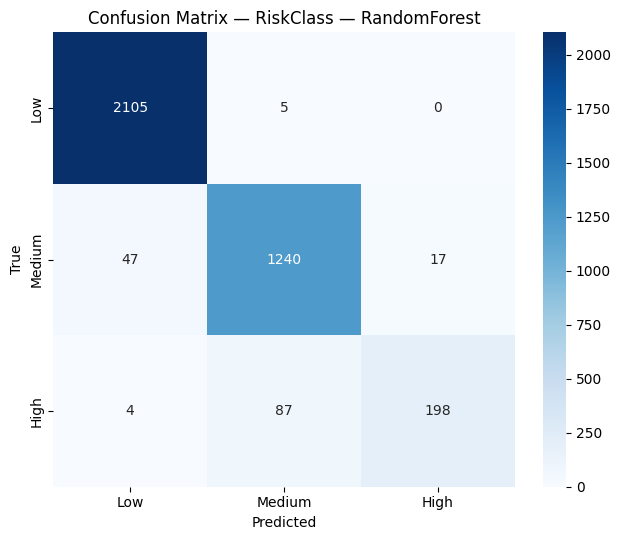

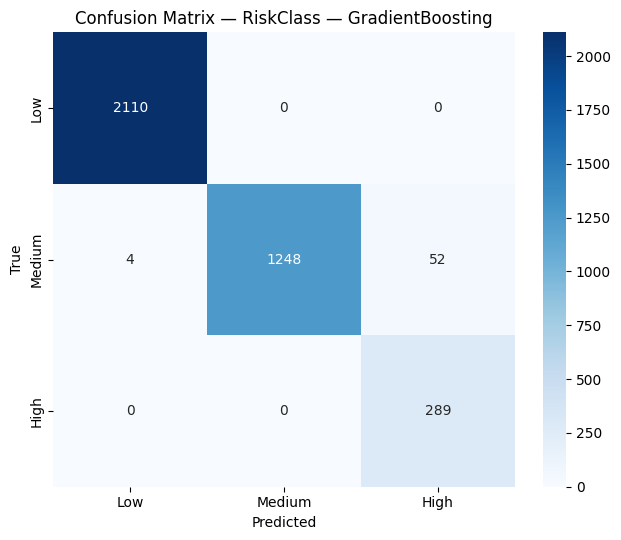

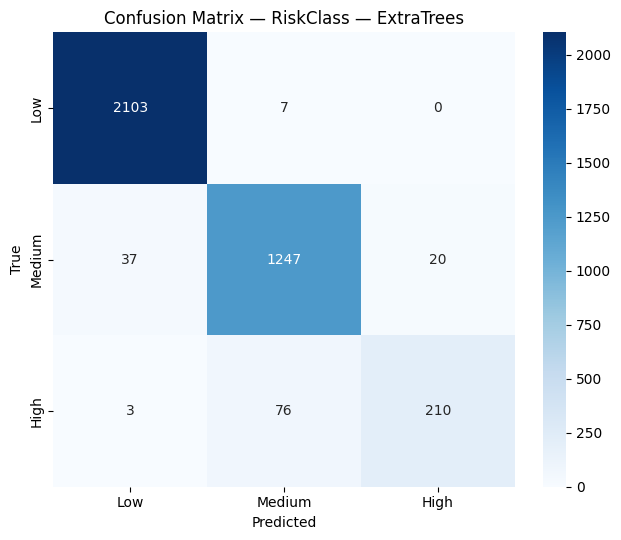

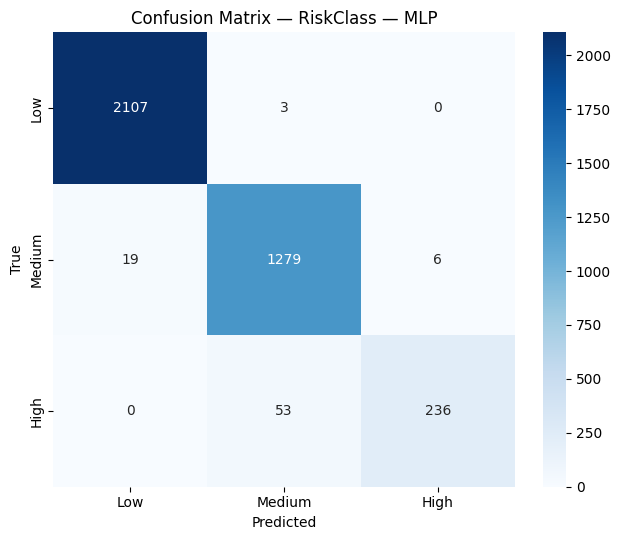

In [ ]:
# Show results
eval_df = pd.DataFrame(results).sort_values(by='F1_macro', ascending=False)
print("\n=== RiskClass (Low/Medium/High) — Temporal Test ===")
print(eval_df.round(4))

# Plot confusion matrices
for name, (cm, labels_sorted) in cms.items():
    plot_cm(cm, labels_sorted, title=f'Confusion Matrix — RiskClass — {name}')

In [ ]:
# Create binary target: High = 1, else 0
y_bin_train = (train_df['RiskClass'] == 'High').astype(int)
y_bin_test  = (test_df['RiskClass'] == 'High').astype(int)

bin_models = {
    'RandomForest_bin': Pipeline(steps=[('prep', preprocess_trees),
                                       ('clf', RandomForestClassifier(n_estimators=400, random_state=42, n_jobs=-1))]),
    'GradientBoosting_bin': Pipeline(steps=[('prep', preprocess_trees),
                                           ('clf', GradientBoostingClassifier(random_state=42))]),
    'ExtraTrees_bin': Pipeline(steps=[('prep', preprocess_trees),
                                     ('clf', ExtraTreesClassifier(n_estimators=600, random_state=42, n_jobs=-1))]),
    'MLP_bin': Pipeline(steps=[('prep', preprocess_mlp),
                               ('clf', MLPClassifier(hidden_layer_sizes=(128, 64), activation='relu',
                                                     solver='adam', alpha=1e-4, batch_size=256,
                                                     learning_rate='adaptive', max_iter=50,
                                                     random_state=42))])
}

bin_results = []
bin_cms = {}


=== Binary High vs Non-High — Temporal Test ===
                  Model  Accuracy  F1_binary  Precision_binary  Recall_binary
0      RandomForest_bin    0.9552     0.5971            1.0000         0.4256
1  GradientBoosting_bin    0.9843     0.9085            0.8348         0.9965
2        ExtraTrees_bin    0.9671     0.7336            0.9941         0.5813
3               MLP_bin    0.9800     0.8598            0.9498         0.7855


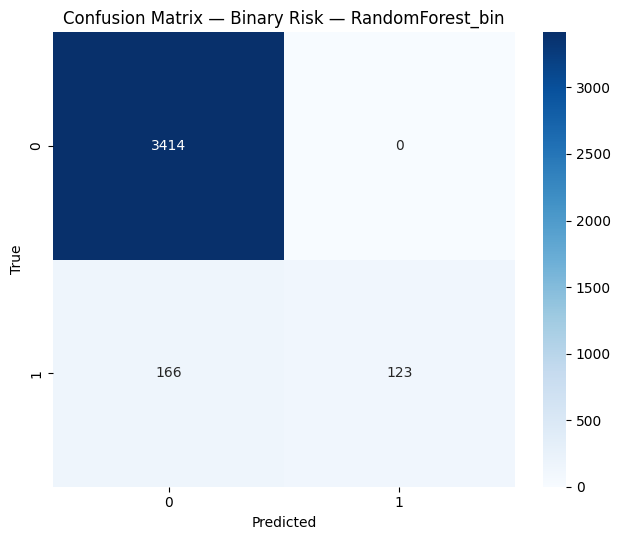

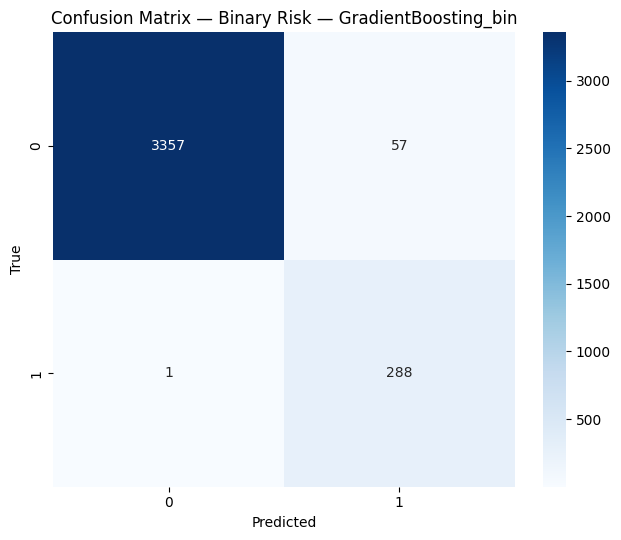

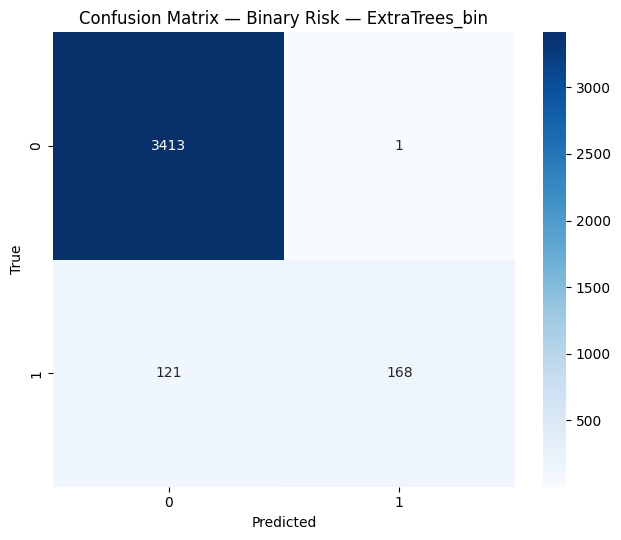

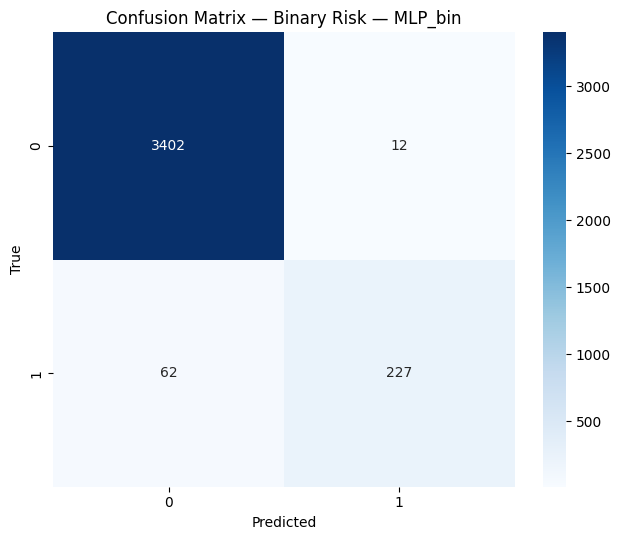

In [ ]:
# Binary imbalance weights (High vs Non-High)
bin_counts = y_bin_train.value_counts()
bin_weights = {cls: (1.0 / cnt) for cls, cnt in bin_counts.items()}
bin_train_weights = y_bin_train.map(bin_weights).values

for name, pipe in bin_models.items():
    if 'bin' in name and name != 'MLP_bin':
        pipe.fit(X_train_risk, y_bin_train, clf__sample_weight=bin_train_weights)
    elif name == 'MLP_bin':
        pipe.fit(X_train_risk, y_bin_train)
    else:
        pipe.fit(X_train_risk, y_bin_train)

    y_pred_bin = pipe.predict(X_test_risk)

    acc = accuracy_score(y_bin_test, y_pred_bin)
    f1_bin = f1_score(y_bin_test, y_pred_bin, average='binary')
    precision_bin = precision_score(y_bin_test, y_pred_bin, average='binary', zero_division=0)
    recall_bin = recall_score(y_bin_test, y_pred_bin, average='binary', zero_division=0)

    bin_results.append({
        'Model': name,
        'Accuracy': acc,
        'F1_binary': f1_bin,
        'Precision_binary': precision_bin,
        'Recall_binary': recall_bin
    })

    cm_bin = confusion_matrix(y_bin_test, y_pred_bin, labels=[0,1])
    bin_cms[name] = (cm_bin, [0,1])

print("\n=== Binary High vs Non-High — Temporal Test ===")
print(pd.DataFrame(bin_results).round(4))

for name, (cm_bin, labels_bin) in bin_cms.items():
    plot_cm(cm_bin, labels_bin, title=f'Confusion Matrix — Binary Risk — {name}')

✅ Word report generated: Aviation_Safety_ML_Report.docx


In [ ]:
# === Explainability Plot: Permutation Importance (Gradient Boosting) ===
# Loads the saved CSV and produces a publication-ready horizontal bar chart.
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [ ]:
# ---- Config ----
CSV_PATH = "permutation_importance_gb.csv"      # produced by the earlier analysis
FIG_PNG  = "figure_4_2_permutation_importance_gb.png"
FIG_PDF  = "figure_4_2_permutation_importance_gb.pdf"
TOP_N    = 15                                   # number of top features to display
TITLE    = "Permutation Importance — Gradient Boosting (Temporal Test 2023–2025)"

In [ ]:
# ---- Load and prep ----
df_imp = pd.read_csv(CSV_PATH, index_col=0)
df_imp = df_imp.sort_values(by=df_imp.columns[0], ascending=False)
df_imp = df_imp.rename(columns={df_imp.columns[0]: "Importance"})
top = df_imp.head(TOP_N).iloc[::-1]  # reverse for horizontal bar ordering

Text(0, 0.5, 'Feature')

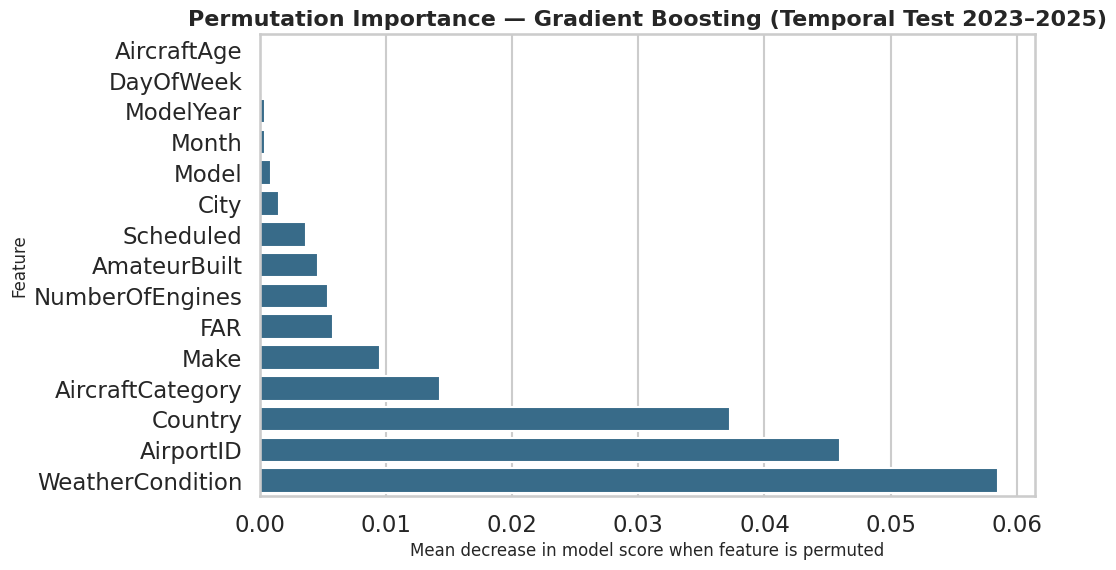

In [ ]:
# ---- Plot style ----
sns.set(style="whitegrid", context="talk")
plt.figure(figsize=(10, 6))
ax = sns.barplot(x="Importance", y=top.index, data=top, color="#2A6F97")
ax.set_title(TITLE, fontsize=16, weight="bold")
ax.set_xlabel("Mean decrease in model score when feature is permuted", fontsize=12)
ax.set_ylabel("Feature", fontsize=12)

In [ ]:
# Annotate bars with values
for i, v in enumerate(top["Importance"]):
    ax.text(v + (0.01 * top["Importance"].max()), i, f"{v:.3f}", va="center", fontsize=10)

plt.tight_layout()
plt.savefig(FIG_PNG, dpi=300)
plt.savefig(FIG_PDF)  # vector for print
plt.show()

print(f"Saved: {FIG_PNG} and {FIG_PDF}")

<Figure size 640x480 with 0 Axes>

Saved: figure_4_2_permutation_importance_gb.png and figure_4_2_permutation_importance_gb.pdf


In [ ]:
# === Explainability Plot computed on-the-fly ===
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.inspection import permutation_importance


In [ ]:
# Assumptions:
# - gb_pipe (Pipeline with preprocess + GradientBoostingClassifier) is fitted
# - X_test, y_test exist
# - FEATURE_COLS is the original (pre-OHE) feature list

TOP_N = 15
TITLE = "Permutation Importance — Gradient Boosting (Temporal Test 2023–2025)"
FIG_PNG = "figure_4_2_permutation_importance_gb.png"
FIG_PDF = "figure_4_2_permutation_importance_gb.pdf"

In [ ]:
# Compute permutation importance on temporal test
r = permutation_importance(gb_pipe, X_test, y_test, n_repeats=8, random_state=42)
imp_mean = pd.Series(r.importances_mean, index=FEATURE_COLS)
imp_std  = pd.Series(r.importances_std,  index=FEATURE_COLS)

df_imp = pd.DataFrame({"Importance": imp_mean, "Std": imp_std}).sort_values("Importance", ascending=False)
top = df_imp.head(TOP_N).iloc[::-1]

Text(0, 0.5, 'Feature')

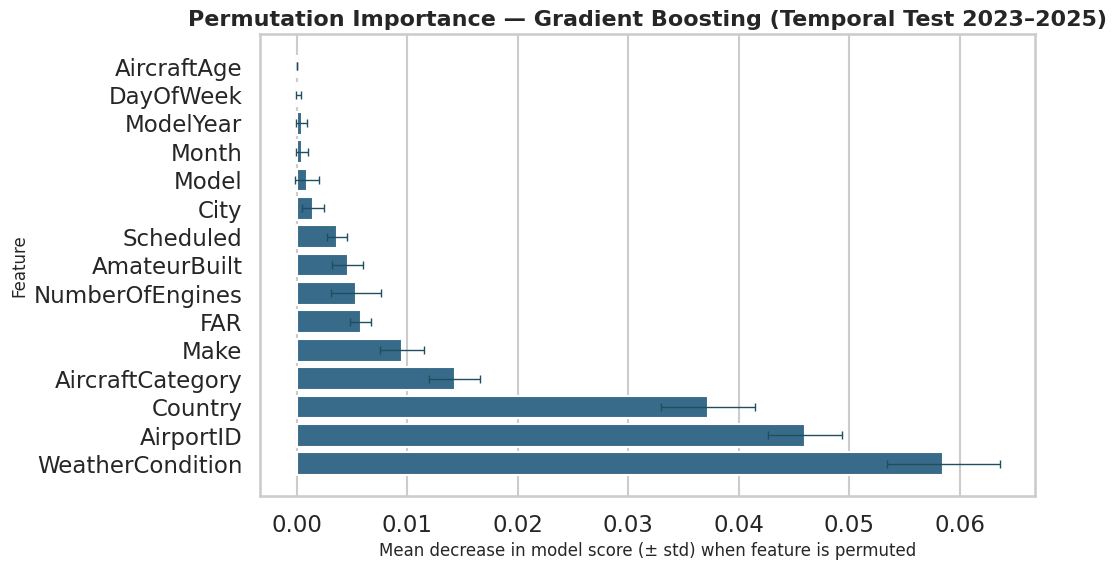

In [ ]:
# Plot
sns.set(style="whitegrid", context="talk")
plt.figure(figsize=(10, 6))
ax = sns.barplot(x="Importance", y=top.index, data=top, color="#2A6F97")

# Error bars (std) for visual robustness
for i, (m, s) in enumerate(zip(top["Importance"], top["Std"])):
    ax.errorbar(x=m, y=i, xerr=s, fmt="none", ecolor="#1F4E5F", capsize=3, lw=1)

ax.set_title(TITLE, fontsize=16, weight="bold")
ax.set_xlabel("Mean decrease in model score (± std) when feature is permuted", fontsize=12)
ax.set_ylabel("Feature", fontsize=12)

In [ ]:
# Annotate bars
for i, v in enumerate(top["Importance"]):
    ax.text(v + (0.01 * top["Importance"].max()), i, f"{v:.3f}", va="center", fontsize=10)

plt.tight_layout()
plt.savefig(FIG_PNG, dpi=300)
plt.savefig(FIG_PDF)
plt.show()

print(f"Saved: {FIG_PNG} and {FIG_PDF}")

<Figure size 640x480 with 0 Axes>

Saved: figure_4_2_permutation_importance_gb.png and figure_4_2_permutation_importance_gb.pdf


In [ ]:
# !pip install shap --quiet
import shap
import numpy as np

# Transform features once with the preprocessing step
X_train_trans = gb_pipe.named_steps['prep'].fit_transform(X_test)
gb_model = gb_pipe.named_steps['clf']


In [ ]:
# Densify if sparse
if hasattr(X_train_trans, "toarray"):
    X_train_trans = X_train_trans.toarray()

try:
    explainer = shap.TreeExplainer(gb_model)
    n_sample = min(2000, X_train_trans.shape[0])
    shap_values = explainer.shap_values(X_train_trans[:n_sample])
    # Optional: If you want to generate the plot here as well
    # shap.summary_plot(shap_values, X_train_trans[:n_sample], show=False)
    # plt.savefig('shap_summary_gb.png', dpi=200, bbox_inches='tight')
    # plt.close()
    # print("Saved SHAP summary to shap_summary_gb.png")
except Exception as e:
    print(f"SHAP explanation for GradientBoostingClassifier skipped due to: {e}")


SHAP explanation for GradientBoostingClassifier skipped due to: GradientBoostingClassifier is only supported for binary classification right now!
